Training on: cuda
Training batches:   938
Test batches:       157

Model parameters: 535,818
Epoch  1/10 | Train: 0.2358 | Test: 0.1107 | Acc: 96.53%
Epoch  2/10 | Train: 0.1124 | Test: 0.0892 | Acc: 97.16%
Epoch  3/10 | Train: 0.0856 | Test: 0.0746 | Acc: 97.57%
Epoch  4/10 | Train: 0.0709 | Test: 0.0733 | Acc: 97.87%
Epoch  5/10 | Train: 0.0632 | Test: 0.0775 | Acc: 97.77%
Epoch  6/10 | Train: 0.0550 | Test: 0.0775 | Acc: 97.61%
Epoch  7/10 | Train: 0.0519 | Test: 0.0634 | Acc: 98.24%
Epoch  8/10 | Train: 0.0491 | Test: 0.0742 | Acc: 97.90%
Epoch  9/10 | Train: 0.0426 | Test: 0.0807 | Acc: 97.73%
Epoch 10/10 | Train: 0.0412 | Test: 0.0668 | Acc: 98.20%

Final Test Accuracy: 98.20%
Model saved to mnist_model.pth


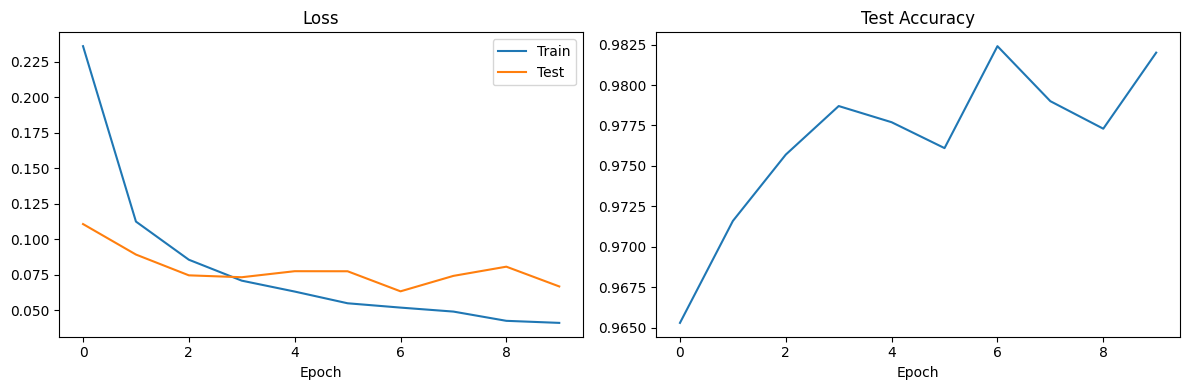

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ─────────────────────────────────────
# CONFIG
# ─────────────────────────────────────
BATCH_SIZE   = 64
EPOCHS       = 10
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Training on: {DEVICE}")

# ─────────────────────────────────────
# DATA
# ─────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Training batches:   {len(train_loader)}")
print(f"Test batches:       {len(test_loader)}")

# ─────────────────────────────────────
# MODEL
# ─────────────────────────────────────
class MNISTNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.network(x)

model   = MNISTNet().to(DEVICE)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")

# ─────────────────────────────────────
# TRAINING
# ─────────────────────────────────────
train_losses = []
test_losses  = []
test_accs    = []

for epoch in range(EPOCHS):

    # ── TRAIN ──
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        preds = model(images)           # forward pass
        loss  = loss_fn(preds, labels)  # calculate loss

        optimizer.zero_grad()  # clear old gradients
        loss.backward()        # calculate new gradients
        optimizer.step()       # update weights

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── EVALUATE ──
    model.eval()
    running_test_loss = 0
    correct = 0
    total   = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            preds = model(images)
            loss  = loss_fn(preds, labels)
            running_test_loss += loss.item()

            predicted = preds.argmax(dim=1)
            correct  += (predicted == labels).sum().item()
            total    += labels.size(0)

    avg_test_loss = running_test_loss / len(test_loader)
    accuracy      = correct / total

    test_losses.append(avg_test_loss)
    test_accs.append(accuracy)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train: {avg_train_loss:.4f} | "
          f"Test: {avg_test_loss:.4f} | "
          f"Acc: {accuracy:.2%}")

# ─────────────────────────────────────
# RESULTS
# ─────────────────────────────────────
print(f"\nFinal Test Accuracy: {test_accs[-1]:.2%}")


os.makedirs("mnist-digit-classifier/models", exist_ok=True)
# Save model
torch.save(model.state_dict(), "mnist-digit-classifier/models/mnist_model.pth")
print("Model saved to mnist_model.pth")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label="Train")
ax1.plot(test_losses,  label="Test")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(test_accs)
ax2.set_title("Test Accuracy")
ax2.set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("training_results.png")
plt.show()